# Pandas Hands-on Lab: From Tables to Real Analysis

## Student Practice Notebook

**Name:** K YUVANYA

**Register Number:** AP24110010974  
**Date:** 14-08-2026

## Learning Objectives

After completing this lab, you will be able to:

- Load and inspect a real dataset with pandas
- Select, filter, and sort rows and columns
- Create new columns from existing ones
- Explore categorical data with `value_counts()`
- Clean data: handle duplicates, missing values, wrong dtypes, and column names
- Summarize data with `groupby()`
- Combine two related tables with `merge()`
- Visualize a DataFrame with matplotlib
- Save your results back to a file

### How to use this notebook
This continues directly from last week's NumPy lab — pandas is built on top of NumPy arrays, so everything you already know about arrays applies here, just organized into labeled rows and columns (a **DataFrame**).

- **Demonstration** cells: run and read.
- **Practice** cells: write your own code.
- **Predict-then-run**: write your prediction before running.
- **Reflection**: short written answers in your own words.


## Part 1: Loading and Inspecting Data

We'll use the classic **tips** dataset — real restaurant bill data. Each row is one bill.

### Demonstration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 10)
pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


**Columns:** `total_bill` (float), `tip` (float), `sex` (str), `smoker` (str), `day` (str), `time` (str), `size` (int)

A pandas **DataFrame** is a 2D table, similar to a NumPy 2D array, but with labeled columns and an index for each row.


In [ ]:
print("Shape:", tips.shape)
print("\nInfo:")
tips.info()


Shape: (244, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


### Student Practice

1. Print `tips.describe()` to see summary statistics.
2. Print the column names using `tips.columns`.
3. Print just the last 5 rows using `tips.tail()`.


In [ ]:
print(tips.describe())

       total_bill      tip     size
count     244.000  244.000  244.000
mean       19.786    2.998    2.570
std         8.902    1.384    0.951
min         3.070    1.000    1.000
25%        13.348    2.000    2.000
50%        17.795    2.900    2.000
75%        24.127    3.562    3.000
max        50.810   10.000    6.000


In [ ]:
print(tips.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


In [ ]:
print(tips.tail())

     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2


**Reflection:** Compare `tips.shape` (NumPy-style) to `tips.info()`. What extra information does `.info()` give you that `.shape` alone doesn't?

**Your answer:**
**tips.shape()**-only gives dimensions of the dataset (number of rows and columns)

**tips.info()**- gives details about column names,data types,how many non-null values

## Part 2: Exploring Categorical Data with `value_counts()`

Before filtering or grouping, it helps to know what categories exist in a column and how common each is.

### Demonstration


In [ ]:
tips['day'].value_counts()


,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


### Student Practice

1. Use `value_counts()` on the `time` column. Which time period has more bills — Lunch or Dinner?

**Ans**:Dinner

2. Use `value_counts()` on `smoker`. What percentage of customers were smokers? (Hint: `value_counts(normalize=True)` gives proportions instead of counts.)

**Ans**:

About 62% of customers were non-smokers.

About 38% of customers were smokers.

In [ ]:
tips['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [ ]:
tips['smoker'].value_counts(normalize=True) * 100

,proportion
smoker,
No,61.885
Yes,38.115


## Part 3: Selecting and Filtering

### Demonstration


In [ ]:
# Select specific columns
tips[['total_bill','tip']].head()


,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [ ]:
# Select rows by position
tips.iloc[0:5]


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Select rows by label/condition using .loc
tips.loc[tips['day']=='Sun', ['total_bill','tip','size']].head()


,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [ ]:
# Boolean filtering (same idea as NumPy boolean indexing!)
big_tables = tips[tips['size'] >= 5]
big_tables.head()


,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.20,Female,No,Thur,Lunch,6
141,34.30,6.70,Male,No,Thur,Lunch,6
142,41.19,5.00,Male,No,Thur,Lunch,5
143,27.05,5.00,Female,No,Thur,Lunch,6
155,29.85,5.14,Female,No,Sun,Dinner,5


**Note the parallel to NumPy:** `tips[tips['size'] >= 5]` uses a boolean condition to filter rows — exactly like `marks[marks > 60]` did with NumPy arrays in last week's lab. The DataFrame version just keeps the whole row instead of a single value.


### Student Practice — predict then check

Before running, predict: how many rows will `tips[(tips['smoker']=='Yes') & (tips['time']=='Lunch')]` return? You don't need an exact number — just predict whether it will be a small or large subset of the 244 total rows, and why.

*Your prediction:*

Since Dinner has far more bills than Lunch, and smokers are already a smaller group (~38%), combining both conditions will narrow it down a lot.

Therefore, this will return only a small subset of the 244 total rows

In [ ]:
tips[(tips['smoker']=='Yes') & (tips['time']=='Lunch')]

,total_bill,tip,sex,smoker,day,time,size
80,19.44,3.00,Male,Yes,Thur,Lunch,2
83,32.68,5.00,Male,Yes,Thur,Lunch,2
138,16.00,2.00,Male,Yes,Thur,Lunch,2
191,19.81,4.19,Female,Yes,Thur,Lunch,2
192,28.44,2.56,Male,Yes,Thur,Lunch,2
...,...,...,...,...,...,...,...
221,13.42,3.48,Female,Yes,Fri,Lunch,2
222,8.58,1.92,Male,Yes,Fri,Lunch,1
224,13.42,1.58,Male,Yes,Fri,Lunch,2
225,16.27,2.50,Female,Yes,Fri,Lunch,2


## Part 4: Sorting

### Demonstration


In [ ]:
tips_sorted = tips.sort_values(['total_bill','tip'], ascending=[False, True])
tips_sorted.head()


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3


### Student Practice

Sort `tips` by `tip` in descending order and display the top 5 highest tips. Which day(s) do they mostly occur on?


In [ ]:
tips.sort_values('tip', ascending=False).head()[['tip','day']]


,tip,day
170,10.00,Sat
212,9.00,Sat
23,7.58,Sat
59,6.73,Sat
141,6.70,Thur


## Part 5: Creating New Columns

### Demonstration


In [ ]:
tips = tips.assign(
    tip_pct = tips['tip'] / tips['total_bill'],
    tip_per_person = tips['tip'] / tips['size']
)
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059,0.505
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161,0.553
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167,1.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140,1.655
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147,0.902


### Student Practice

Filter for `day='Sat'` and `size >= 3`, add a new column `bill_per_person = total_bill / size`, then sort descending by that column and show the top 5.


In [ ]:
sat_groups = tips[(tips['day']=='Sat') & (tips['size']>=3)]
sat_groups = sat_groups.assign(bill_per_person = sat_groups['total_bill'] / sat_groups['size'])
sat_groups.sort_values('bill_per_person', ascending=False).head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person,bill_per_person
170,50.81,10.00,Male,Yes,Sat,Dinner,3,0.197,3.333,16.937
102,44.30,2.50,Female,Yes,Sat,Dinner,3,0.056,0.833,14.767
212,48.33,9.00,Male,No,Sat,Dinner,4,0.186,2.250,12.082
59,48.27,6.73,Male,No,Sat,Dinner,4,0.139,1.683,12.068
238,35.83,4.67,Female,No,Sat,Dinner,3,0.130,1.557,11.943


## Part 6: Cleaning Data

Real data is rarely perfect. We'll cover 4 common cleaning tasks: duplicates, missing values, wrong dtypes, and messy column names.

### 6a. Duplicates


In [ ]:
print("Duplicate rows:", tips.duplicated().sum())
tips_clean = tips.drop_duplicates()
print("Shape after dropping duplicates:", tips_clean.shape)


Duplicate rows: 1
Shape after dropping duplicates: (243, 9)


### 6b. Missing Values

Let's deliberately introduce some missing values to practice on, since the original dataset is clean.

In [ ]:
tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

print("Missing values per column:")
print(tips_messy.isna().sum())


Missing values per column:
total_bill        4
tip               0
sex               0
smoker            0
day               1
time              0
size              0
tip_pct           0
tip_per_person    0
dtype: int64


### Student Practice

1. Drop rows with any missing values using `.dropna()` and check the new shape.
2. Instead of dropping, fill missing `total_bill` values with the column's mean using `.fillna()`. Compare the two approaches — when would you choose one over the other?


In [ ]:
import seaborn as sns
import numpy as np

tips = sns.load_dataset("tips")

tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

tips_dropna = tips_messy.dropna()
print("Shape after dropna:", tips_dropna.shape)

Shape after dropna: (239, 7)


In [ ]:
import seaborn as sns
import numpy as np

tips = sns.load_dataset("tips")

tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

tips_fillna = tips_messy.copy()
tips_fillna['total_bill'] = tips_fillna['total_bill'].fillna(tips_fillna['total_bill'].mean())

print("Missing values after fillna:")
print(tips_fillna.isna().sum())

Missing values after fillna:
total_bill    0
tip           0
sex           0
smoker        0
day           1
time          0
size          0
dtype: int64


**Drop rows (dropna)** : Best when missing data is rare and you don’t mind losing a few records. It keeps the dataset accurate but reduces its size.

**Fill with mean (fillna)** : Best when you want to keep all rows. It preserves dataset size but introduces approximate values, which may slightly distort the data.

### 6c. Fixing Data Types

### Demonstration


In [ ]:
tips_dtypes = tips.copy()
print("Before:", tips_dtypes['size'].dtype)

tips_dtypes['size'] = tips_dtypes['size'].astype('int32')
tips_dtypes['day'] = tips_dtypes['day'].astype('category')

print("After:", tips_dtypes['size'].dtype, tips_dtypes['day'].dtype)


Before: int64
After: int32 category


### 6d. Renaming Columns

### Demonstration


In [ ]:
tips_renamed = tips.rename(columns={'size': 'party_size', 'tip_pct': 'tip_percentage'})
tips_renamed.columns


Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'party_size'], dtype='object')

### Student Practice

Rename `total_bill` to `bill_amount` and `smoker` to `is_smoker` in a copy of `tips`. Print the new column list to confirm.


In [ ]:
tips_renamed = tips.rename(columns={'total_bill': 'bill_amount', 'smoker': 'is_smoker'})
print(tips_renamed.columns)


Index(['bill_amount', 'tip', 'sex', 'is_smoker', 'day', 'time', 'size'], dtype='object')


## Part 7: Summarizing with `groupby()`

`groupby()` is one of the most powerful pandas tools — it splits data into groups, applies a calculation to each group, then combines the results. This is the tabular equivalent of the `np.mean()` per-category calculations you'd otherwise have to write manually with loops.

### Demonstration


In [ ]:
tips.groupby('day')['total_bill'].mean()


/tmp/ipykernel_1723/983894002.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('day')['total_bill'].mean()


,total_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


In [ ]:
# Multiple aggregations at once
tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean'),
    n_bills=('total_bill','size')
)


/tmp/ipykernel_1723/4086658732.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('day').agg(


,avg_bill,avg_tip,n_bills
day,,,
Thur,17.682742,2.771452,62
Fri,17.151579,2.734737,19
Sat,20.441379,2.993103,87
Sun,21.410000,3.255132,76


### Student Practice — predict then check

Predict: will average tip percentage (`tip_pct`) be higher at Lunch or Dinner? Write your guess, then check with `groupby('time')['tip_pct'].mean()`.

**Your prediction:**
Dinner

In [ ]:
import seaborn as sns
import numpy as np

tips = sns.load_dataset("tips")

tips_messy = tips.copy()
tips_messy.loc[5:8, 'total_bill'] = np.nan
tips_messy.loc[15, 'day'] = np.nan

tips['tip_pct'] = tips['tip'] / tips['total_bill']

print("Average tip percentage by time:")
print(tips.groupby('time')['tip_pct'].mean())

Average tip percentage by time:
time
Lunch     0.164128
Dinner    0.159518
Name: tip_pct, dtype: float64


/tmp/ipykernel_1723/758224986.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby('time')['tip_pct'].mean())


**Reflection:** In your own words, explain what `groupby()` does, using the day/total_bill example above.

**Your answer:**
groupby() splits the dataset into groups based on a column, applies a calculation to each group, and then combines the results. For example, in tips.groupby('day')['total_bill'].mean(), the data is grouped by day, the average of total_bill is calculated for each day, and the results are returned as a summary table.


## Part 8: Merging Two Tables

Real-world data often lives in separate tables that need to be joined — e.g. a customer table and an orders table. Let's create a small second table and merge it with `tips`.

### Demonstration


In [ ]:
import pandas as pd
import seaborn as sns

tips = sns.load_dataset("tips")

tips['tip_pct'] = tips['tip'] / tips['total_bill']

day_benchmark = pd.DataFrame({
    'day': ['Thur','Fri','Sat','Sun'],
    'benchmark_tip_pct': [0.15, 0.16, 0.18, 0.17]
})

merged = tips.merge(day_benchmark, on='day', how='left')
merged[['day','tip_pct','benchmark_tip_pct']].head()

,day,tip_pct,benchmark_tip_pct
0,Sun,0.059447,0.17
1,Sun,0.160542,0.17
2,Sun,0.166587,0.17
3,Sun,0.139780,0.17
4,Sun,0.146808,0.17


### Student Practice

Create your own small DataFrame called `time_rating` with two columns: `time` (`Lunch`, `Dinner`) and `popularity_score` (any numbers you choose, e.g. 7 and 9). Merge it with `tips` on the `time` column and display the first 5 rows of the result.


In [ ]:
import pandas as pd
import seaborn as sns

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / tips['total_bill']

time_rating = pd.DataFrame({
    'time': ['Lunch', 'Dinner'],
    'popularity_score': [7, 9]
})

merged = tips.merge(time_rating, on='time', how='left')

print(merged.head())


   total_bill   tip     sex smoker  day    time  size   tip_pct  \
0       16.99  1.01  Female     No  Sun  Dinner     2  0.059447   
1       10.34  1.66    Male     No  Sun  Dinner     3  0.160542   
2       21.01  3.50    Male     No  Sun  Dinner     3  0.166587   
3       23.68  3.31    Male     No  Sun  Dinner     2  0.139780   
4       24.59  3.61  Female     No  Sun  Dinner     4  0.146808   

   popularity_score  
0                 9  
1                 9  
2                 9  
3                 9  
4                 9  


## Part 9: Visualization

### Demonstration


/tmp/ipykernel_1723/4285258685.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = tips.groupby('day')['total_bill'].mean()


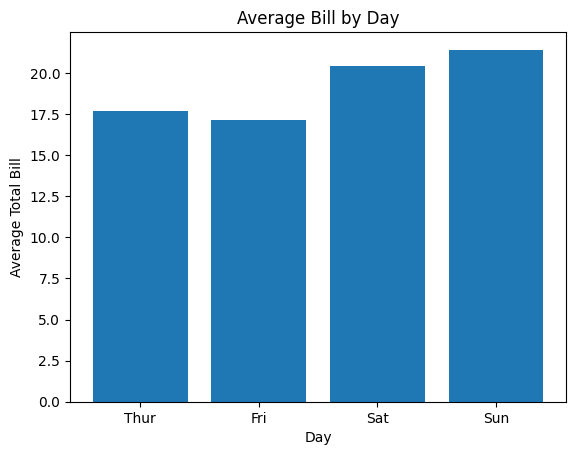

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / tips['total_bill']

avg_by_day = tips.groupby('day')['total_bill'].mean()

plt.figure()
plt.bar(avg_by_day.index.astype(str), avg_by_day.values)
plt.title("Average Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

### Student Practice

Create a bar chart showing average `tip_pct` by `time` (Lunch vs Dinner). Give it a title and axis labels.


/tmp/ipykernel_1723/1135378250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_time = tips.groupby('time')['tip_pct'].mean()


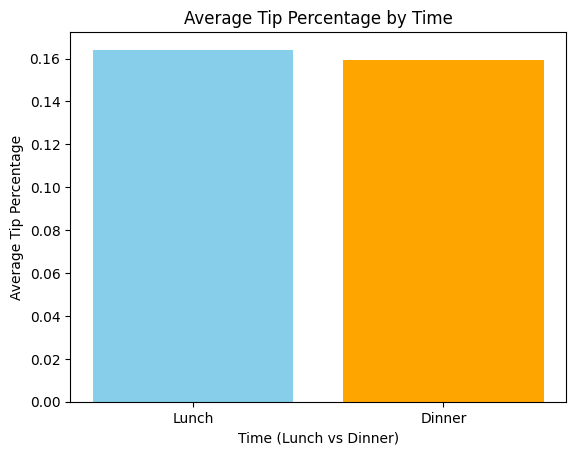

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / tips['total_bill']

avg_by_time = tips.groupby('time')['tip_pct'].mean()

plt.figure()
plt.bar(avg_by_time.index.astype(str), avg_by_time.values, color=['skyblue','orange'])
plt.title("Average Tip Percentage by Time")
plt.xlabel("Time (Lunch vs Dinner)")
plt.ylabel("Average Tip Percentage")
plt.show()

## Part 10: Saving Your Work

### Demonstration


In [ ]:
summary = tips.groupby('day').agg(
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean')
).round(2)

summary.to_csv('day_summary.csv')
print("Saved day_summary.csv")
summary


Saved day_summary.csv


/tmp/ipykernel_1723/3255454896.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = tips.groupby('day').agg(


,avg_bill,avg_tip
day,,
Thur,17.68,2.77
Fri,17.15,2.73
Sat,20.44,2.99
Sun,21.41,3.26


### Student Practice

Save a CSV called `my_time_summary.csv` containing the average `total_bill` and `tip_pct` grouped by `time`.


In [ ]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset("tips")
tips['tip_pct'] = tips['tip'] / tips['total_bill']

time_summary = tips.groupby('time').agg(
    avg_bill=('total_bill','mean'),
    avg_tip_pct=('tip_pct','mean')
).round(2)

time_summary.to_csv('my_time_summary.csv')
print("Saved my_time_summary.csv")

print(time_summary)

Saved my_time_summary.csv
        avg_bill  avg_tip_pct
time                         
Lunch      17.17         0.16
Dinner     20.80         0.16


/tmp/ipykernel_1723/2800968732.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_summary = tips.groupby('time').agg(


**Reflection:** Why might you want to save intermediate results (like `summary`) to a CSV instead of just leaving them as a variable in the notebook?

**Your answer:**
CSV files make your analysis portable, reusable, and safe from accidental loss.


# Mini Project A: Image Metadata Analysis (Image Track — continuing from NumPy lab)

Last week you analyzed a single image with NumPy (shape, brightness, RGB channels). Now you'll use pandas to compare **multiple images** at once — this is exactly how you'd organize a small image dataset for a computer vision project.

## Step 1: Build an image metadata table

For this project, upload **3-5 images** to Colab (reuse your NumPy lab technique), then build a DataFrame — one row per image — with columns: `filename`, `height`, `width`, `channels`, `avg_brightness`, `avg_red`, `avg_green`, `avg_blue`.

### Demonstration: the pattern for one image


In [1]:
from google.colab import files
uploaded = files.upload()


Saving cat.jpg to cat.jpg
Saving rabbit.jpg to rabbit.jpg
Saving panda.jpg to panda.jpg
Saving squirrel.jpg to squirrel.jpg


In [2]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
print("Uploaded files:", filenames)

# Demonstration: extract metadata for ONE image
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

row = {
    'filename': sample_name,
    'height': img_array.shape[0],
    'width': img_array.shape[1],
    'channels': img_array.shape[2] if img_array.ndim == 3 else 1,
    'avg_brightness': np.mean(img_array),
    'avg_red': np.mean(img_array[:,:,0]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_green': np.mean(img_array[:,:,1]) if img_array.ndim == 3 else np.mean(img_array),
    'avg_blue': np.mean(img_array[:,:,2]) if img_array.ndim == 3 else np.mean(img_array),
}
print(row)


Uploaded files: ['cat.jpg', 'rabbit.jpg', 'panda.jpg', 'squirrel.jpg']
{'filename': 'cat.jpg', 'height': 419, 'width': 236, 'channels': 3, 'avg_brightness': np.float64(179.71223521162844), 'avg_red': np.float64(182.22391893531815), 'avg_green': np.float64(181.44962784676994), 'avg_blue': np.float64(175.46315885279722)}


### Student Practice

Loop over **all** uploaded `filenames` (not just the first one), build a `row` dictionary like above for each image, collect them into a list, and convert the list into a DataFrame using `pd.DataFrame(list_of_rows)`.


In [3]:
from google.colab import files
from PIL import Image
import numpy as np
import pandas as pd

uploaded = files.upload()

rows = []

for filename in uploaded.keys():
    img_array = np.array(Image.open(filename))

    row = {
        'filename': filename,
        'height': img_array.shape[0],
        'width': img_array.shape[1],
        'channels': img_array.shape[2] if img_array.ndim == 3 else 1,
        'avg_brightness': np.mean(img_array),
        'avg_red': np.mean(img_array[:,:,0]) if img_array.ndim == 3 else np.mean(img_array),
        'avg_green': np.mean(img_array[:,:,1]) if img_array.ndim == 3 else np.mean(img_array),
        'avg_blue': np.mean(img_array[:,:,2]) if img_array.ndim == 3 else np.mean(img_array),
    }
    rows.append(row)

df = pd.DataFrame(rows)

print(df)


Saving cat.jpg to cat (1).jpg
Saving rabbit.jpg to rabbit (1).jpg
Saving panda.jpg to panda (1).jpg
Saving squirrel.jpg to squirrel (1).jpg
           filename  height  width  channels  avg_brightness     avg_red  \
0       cat (1).jpg     419    236         3      179.712235  182.223919   
1    rabbit (1).jpg    1022    736         3      130.525454  135.802895   
2     panda (1).jpg     720    597         3       79.176584   80.200414   
3  squirrel (1).jpg    3055   3055         3       91.708924   98.911505   

    avg_green    avg_blue  
0  181.449628  175.463159  
1  126.590841  129.182628  
2   89.700072   67.629267  
3  107.535379   68.679887  


## Step 2: Analyze the image table with pandas

Once you have your image DataFrame, answer using pandas (not manual calculation):

1. Which image has the highest average brightness? (Hint: `.sort_values()` or `.idxmax()`)-
**Cat**
2. What is the average brightness across all your images? (`.mean()`)-
**120.28**
3. Create a bar chart comparing `avg_brightness` across all images (reuse Part 9's pattern).


Brightest image: cat (1).jpg
Average brightness across all images: 120.28079949287029


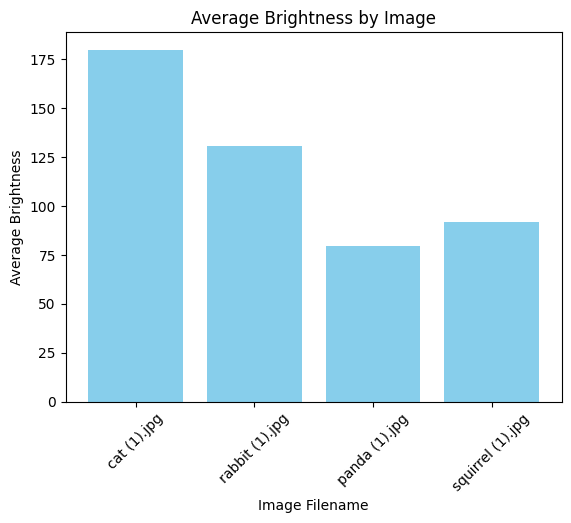

In [4]:
import matplotlib.pyplot as plt

brightest_image = df.loc[df['avg_brightness'].idxmax()]
print("Brightest image:", brightest_image['filename'])

overall_avg_brightness = df['avg_brightness'].mean()
print("Average brightness across all images:", overall_avg_brightness)

plt.figure()
plt.bar(df['filename'], df['avg_brightness'], color='skyblue')
plt.title("Average Brightness by Image")
plt.xlabel("Image Filename")
plt.ylabel("Average Brightness")
plt.xticks(rotation=45)
plt.show()

**Reflection:** How is organizing multiple images into a DataFrame more useful than analyzing them one at a time like you did last week?

**Your answer:**
A DataFrame is more useful because it lets you see and compare all images together in one table.It makes calculations easier and faster than analyzing each image one by one.


# Mini Project B: Word Frequency Table (NLP Track — continuing from NumPy lab)

Last week you built bag-of-words vectors and cosine similarity using raw NumPy. Now you'll organize word frequency data into a pandas DataFrame — the standard way this is done in real NLP pipelines.

## Step 1: Build a word frequency table

### Demonstration


In [5]:
sentence = "numpy makes numerical computing fast and numpy makes arrays powerful and pandas makes tables powerful"

tokens = sentence.lower().split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)

counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})
word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)
word_freq


,word,count
0,makes,3
1,and,2
2,powerful,2
3,numpy,2
4,arrays,1
5,computing,1
6,numerical,1
7,fast,1
8,pandas,1
9,tables,1


### Student Practice

1. Pick a paragraph of your own (3-4 sentences). Build a `word_freq` DataFrame for it using the same pattern.
2. Use pandas to find the top 5 most frequent words (`.head(5)`).
3. Use pandas to find how many words appear **only once** (Hint: filter where `count == 1`, then check `.shape[0]`).


In [6]:
import numpy as np
import pandas as pd

paragraph = """Generative AI is a powerful technology that creates new content such as text, images, and music.
It learns patterns from large datasets and then generates outputs that look human-made.
GenAI tools like ChatGPT and image generators are transforming education, business, and creativity.
They make tasks faster, more efficient, and open new possibilities for innovation."""

tokens = paragraph.lower().split()
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)

counts = [np.sum(tokens_array == word) for word in vocabulary]

word_freq = pd.DataFrame({'word': vocabulary, 'count': counts})
word_freq = word_freq.sort_values('count', ascending=False).reset_index(drop=True)
print(word_freq)

print("Top 5 words:\n", word_freq.head(5))

unique_count = word_freq[word_freq['count'] == 1].shape[0]
print("Number of words that appear only once:", unique_count)


             word  count
0             and      5
1            that      2
2             new      2
3               a      1
4              as      1
5       business,      1
6              ai      1
7             are      1
8         creates      1
9     creativity.      1
10       datasets      1
11     education,      1
12     efficient,      1
13        faster,      1
14        chatgpt      1
15        content      1
16           from      1
17            for      1
18          genai      1
19      generates      1
20    human-made.      1
21          image      1
22     generative      1
23     generators      1
24             is      1
25             it      1
26          large      1
27         learns      1
28           like      1
29           look      1
30        images,      1
31    innovation.      1
32           more      1
33           make      1
34           open      1
35         music.      1
36       patterns      1
37  possibilities      1
38       powerful      1


## Step 2: Compare word frequency across multiple sentences

### Demonstration: build one table with per-sentence word counts


In [7]:
sentence_a = "machine learning uses numpy and pandas"
sentence_b = "deep learning also uses numpy and pandas heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

table = pd.DataFrame({
    'word': combined_vocab,
    'sentence_a_count': [np.sum(np.array(tokens_a) == w) for w in combined_vocab],
    'sentence_b_count': [np.sum(np.array(tokens_b) == w) for w in combined_vocab],
})
table


,word,sentence_a_count,sentence_b_count
0,also,0,1
1,and,1,1
2,deep,0,1
3,heavily,0,1
4,learning,1,1
5,machine,1,0
6,numpy,1,1
7,pandas,1,1
8,uses,1,1


### Student Practice

Using the `table` above:
1. Add a new column `difference` = `sentence_a_count - sentence_b_count`.
2. Sort by `difference` to find which words are most unique to sentence A vs sentence B.
3. Which words appear in **both** sentences (count > 0 in both columns)? Filter and display them.


In [8]:
import numpy as np
import pandas as pd

sentence_a = "machine learning uses numpy and pandas"
sentence_b = "deep learning also uses numpy and pandas heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

table = pd.DataFrame({
    'word': combined_vocab,
    'sentence_a_count': [np.sum(np.array(tokens_a) == w) for w in combined_vocab],
    'sentence_b_count': [np.sum(np.array(tokens_b) == w) for w in combined_vocab],
})

table['difference'] = table['sentence_a_count'] - table['sentence_b_count']
print("Table with difference:\n", table)

sorted_table = table.sort_values('difference', ascending=False)
print("Sorted by difference:\n", sorted_table)

common_words = table[(table['sentence_a_count'] > 0) & (table['sentence_b_count'] > 0)]
print("Words in both sentences:\n", common_words)


Table with difference:
        word  sentence_a_count  sentence_b_count  difference
0      also                 0                 1          -1
1       and                 1                 1           0
2      deep                 0                 1          -1
3   heavily                 0                 1          -1
4  learning                 1                 1           0
5   machine                 1                 0           1
6     numpy                 1                 1           0
7    pandas                 1                 1           0
8      uses                 1                 1           0
Sorted by difference:
        word  sentence_a_count  sentence_b_count  difference
5   machine                 1                 0           1
7    pandas                 1                 1           0
1       and                 1                 1           0
6     numpy                 1                 1           0
4  learning                 1                 1      

**Reflection:** Compare this pandas approach to building the same information with raw NumPy arrays last week. What does pandas make easier, and what (if anything) does it hide from you that NumPy made explicit?

**Your answer:**
Pandas makes building word frequency tables easier by giving direct functions to sort, filter, and display results clearly. NumPy required manual array handling, which was more explicit but harder to manage. Pandas hides that low‑level detail and saves effort.


# Final Self-Check

- [ ] I loaded and inspected a real dataset using pandas
- [ ] I filtered, sorted, and created new columns myself
- [ ] I cleaned data (duplicates, missing values, dtypes, renaming) without just copying the demo
- [ ] I used `groupby()` to summarize data by category
- [ ] I merged two tables together
- [ ] I built at least one chart from a DataFrame
- [ ] I completed Mini Project A (image metadata) or B (word frequency), building the DataFrame myself
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. How is a pandas DataFrame related to a NumPy array? (Think back to last week's lab.)

**Answer:** A pandas DataFrame is built on top of NumPy arrays. It adds labeled rows and columns, making data easier to read and manipulate compared to raw arrays.

2. Name one pandas operation that would be painful to do with raw NumPy arrays and loops instead, and explain why.

**Answer:** Sorting and filtering by column values is simple in pandas (.sort_values(), boolean indexing), but with NumPy you’d need manual loops and index tracking, which is more complex and error‑prone.

3. Between the image metadata project and the word frequency project, which felt more like "real world data work" to you, and why?

**Answer:** The word frequency project felt more like real‑world data work because text analysis is common in NLP, search engines, and chatbots, and pandas made it easy to organize and compare word counts.

4. What's one pandas concept from this lab you still feel shaky on? Be specific — this helps guide review.

**Answer:** .groupby()
